# Stellar Mass Function Example

Stellar mass function for a few subvolumes at `iz155` 

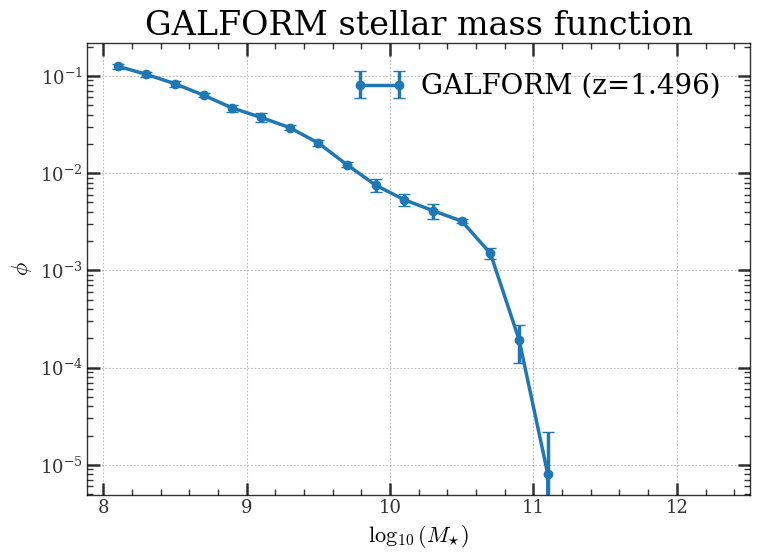

In [3]:
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'galform_analysis').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root containing galform_analysis/')


repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.setconfig()

from galform_analysis.analysis.mass_functions.smf import avg_smf_given_redshift_and_subvolumes
from galform_analysis.config import get_base_dir, get_snapshot_redshift

iz_name = 'iz155'
iz_num = 155
ivols = [0, 1, 2, 3]

target_z = get_snapshot_redshift(iz_name, 'L800')
res = avg_smf_given_redshift_and_subvolumes(iz_num, ivols, base_dir=str(get_base_dir()))

fig, ax = plt.subplots(figsize=(8, 6))
if 'phi_std' in res and res['phi_std'] is not None:
    ax.errorbar(res['centers'], res['phi'], yerr=res['phi_std'], fmt='o-', label=f'GALFORM (z={target_z:.3f})')
else:
    ax.plot(res['centers'], res['phi'], 'o-', lw=1.5, label=f'GALFORM (z={target_z:.3f})')
ax.set_yscale('log')
ax.set_xlabel(r'$\log_{10}(M_{\star})$')
ax.set_ylabel(r'$\phi$')
ax.set_title('GALFORM stellar mass function')
ax.legend()
fig.tight_layout()
plt.show()